# 12 - Muon 优化器 (AI Infra 视角)

本节从 **工程实现** 角度理解 Muon 优化器，重点关注：
- Newton-Schulz 正交化算法
- 与 AdamW 的分工策略
- Aspect ratio scaling
- 分布式 DistMuon 实现

> Muon = **Mo**ment**u**m + **N**ewton-schulz orthogonalization

In [ ]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt

## 1. 核心概念 (30秒版)

```
Muon = SGD-Momentum + Newton-Schulz 正交化

步骤:
  1. 计算梯度 G
  2. 用动量平滑: buf = momentum * buf + (1-momentum) * G
  3. Nesterov 前瞻: G' = lerp(G, buf, momentum)
  4. Newton-Schulz 正交化: G'' ≈ U S' V^T → 去掉尺度信息
  5. Aspect ratio scaling: lr *= sqrt(max(1, rows/cols))
  6. 更新参数: param -= lr * G''
```

**关键直觉**: 梯度矩阵经过正交化后，所有方向的更新步长一致，避免某些方向更新过大或过小。

## 2. 为什么需要 Muon?

### AdamW 的局限

AdamW 对每个标量参数独立地做自适应学习率 (通过 `v`)，但它 **不考虑参数之间的关联**。

对于权重矩阵，梯度的奇异值分布往往很不均匀：
- 大奇异值方向: 信号强，但容易 overshoot
- 小奇异值方向: 信号弱，但容易被忽略

### Muon 的思路

| | AdamW | Muon |
|---|---|---|
| 适应粒度 | 逐元素 | 逐矩阵 (SVD 级别) |
| 更新方向 | 沿梯度方向 | 正交化后的方向 |
| 步长控制 | 二阶动量 `v` | 正交化消除尺度差异 |
| 适用范围 | 任何参数 | 仅 2D 矩阵参数 |
| 状态量 | m + v (2x) | 仅 momentum buffer (1x) |

In [2]:
# 直觉演示: 正交化如何"均匀化"更新方向

torch.manual_seed(42)

# 模拟一个梯度矩阵，奇异值差异很大
U, _ = torch.linalg.qr(torch.randn(4, 4))
V, _ = torch.linalg.qr(torch.randn(4, 4))
S = torch.diag(torch.tensor([10.0, 3.0, 0.5, 0.1]))  # 100x 差异
G = U @ S @ V.T

# SVD 正交化: U @ V^T (去掉奇异值)
U_svd, S_svd, Vh_svd = torch.linalg.svd(G, full_matrices=False)
G_orth = U_svd @ Vh_svd

print("原始梯度 G 的奇异值:", torch.linalg.svdvals(G).tolist())
print("正交化后的奇异值:  ", torch.linalg.svdvals(G_orth).tolist())
print()
print("正交化让所有方向的'步长'变一致 (全部为 1.0)")

原始梯度 G 的奇异值: [10.000000953674316, 3.000000476837158, 0.49999985098838806, 0.10000018030405045]
正交化后的奇异值:   [1.0000001192092896, 1.0, 0.9999999403953552, 0.9999998211860657]

正交化让所有方向的'步长'变一致 (全部为 1.0)


## 3. Newton-Schulz 迭代

直接做 SVD 太贵 (O(n³))，Muon 用 **Newton-Schulz 迭代** 来近似正交化。

### 算法

给定矩阵 X (谱范数归一化到 ≤1)，迭代:

```
X_{k+1} = a * X_k + (b * X_k @ X_k^T + c * X_k @ X_k^T @ X_k @ X_k^T) @ X_k
```

其中 `a, b, c = 3.4445, -4.7750, 2.0315` 是五次多项式的系数，
选择标准是 **最大化在零点的斜率**，从而加速收敛。

### 为什么这组系数?

- 经典 Newton-Schulz: `X_{k+1} = 1.5*X - 0.5*X@X^T@X` (三次，收敛慢)
- nanochat 用五次变体: 更激进的系数让收敛更快
- 代价: 不完全收敛到 UV^T，而是 US'V^T (S' ~ Uniform(0.5, 1.5))
- **这不影响训练效果**，因为奇异值已经"足够均匀"了

C:\Users\lagoo\AppData\Local\Temp\ipykernel_35256\737544854.py:70: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lagoo\AppData\Local\Temp\ipykernel_35256\737544854.py:70: UserWarning: Glyph 25947 (\N{CJK UNIFIED IDEOGRAPH-655B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lagoo\AppData\Local\Temp\ipykernel_35256\737544854.py:70: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lagoo\AppData\Local\Temp\ipykernel_35256\737544854.py:70: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lagoo\AppData\Local\Temp\ipykernel_35256\737544854.py:70: UserWarning: Glyph 22855 (\N{CJK UNIFIED IDEOGRAPH-5947}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lagoo\AppData\Local\Temp\ipykernel_35256\737544854.py:70: UserWarning: Glyph 24322 (\N{CJK 

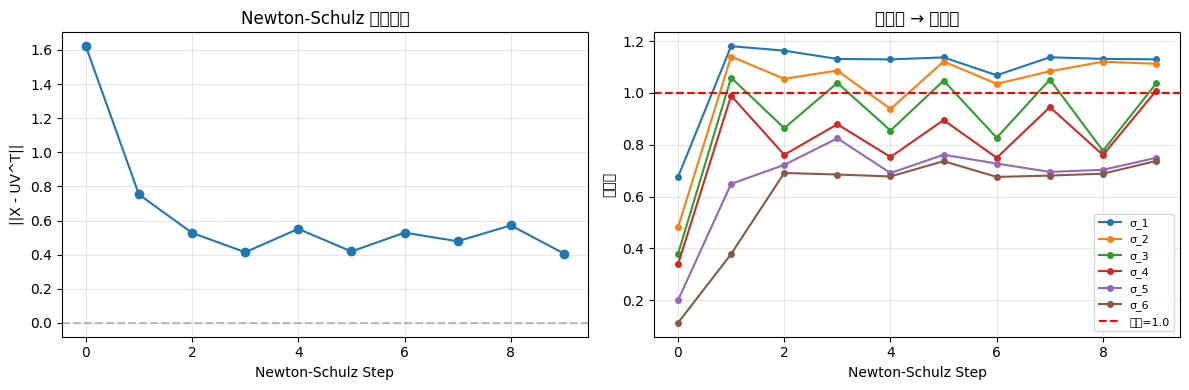


5 步后奇异值: ['1.138', '1.122', '1.048', '0.895', '0.761', '0.737']
可以看到奇异值大致在 [0.5, 1.5] 范围内，不完全收敛到 1.0
但这对训练效果没有影响


In [3]:
def zeropower_via_newtonschulz5(G, steps=5):
    """
    Newton-Schulz 迭代: 将矩阵 G 正交化
    结果近似 U S' V^T，其中 S' ~ Uniform(0.5, 1.5)
    """
    assert G.ndim >= 2
    a, b, c = (3.4445, -4.7750, 2.0315)
    X = G.bfloat16()
    if G.size(-2) > G.size(-1):
        X = X.mT  # 转置使得 rows <= cols，节省计算

    # 谱范数归一化
    X = X / (X.norm(dim=(-2, -1), keepdim=True) + 1e-7)
    # 迭代
    for _ in range(steps):
        A = X @ X.mT
        B = b * A + c * A @ A
        X = a * X + B @ X

    if G.size(-2) > G.size(-1):
        X = X.mT
    return X


# 演示: 迭代收敛过程
torch.manual_seed(42)
G = torch.randn(8, 6)

# 真正的 SVD 结果
U_true, _, Vh_true = torch.linalg.svd(G, full_matrices=False)
target = U_true @ Vh_true  # UV^T

# 逐步迭代并观察
a, b, c = (3.4445, -4.7750, 2.0315)
X = G.bfloat16()
X = X / (X.norm(dim=(-2, -1), keepdim=True) + 1e-7)

svd_errors = []
singular_vals_per_step = []
for step in range(10):
    sv = torch.linalg.svdvals(X.float()).tolist()
    singular_vals_per_step.append(sv)
    err = (X.float() - target).norm().item()
    svd_errors.append(err)
    A = X @ X.mT
    B = b * A + c * A @ A
    X = a * X + B @ X

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图: 与 UV^T 的距离
axes[0].plot(svd_errors, 'o-')
axes[0].set_xlabel('Newton-Schulz Step')
axes[0].set_ylabel('||X - UV^T||')
axes[0].set_title('Newton-Schulz 收敛过程')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# 右图: 奇异值变化
for i in range(len(singular_vals_per_step[0])):
    vals = [sv[i] for sv in singular_vals_per_step]
    axes[1].plot(vals, 'o-', label=f'σ_{i+1}', markersize=4)
axes[1].axhline(y=1.0, color='red', linestyle='--', label='目标=1.0')
axes[1].set_xlabel('Newton-Schulz Step')
axes[1].set_ylabel('奇异值')
axes[1].set_title('奇异值 → 均匀化')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n5 步后奇异值: {[f'{v:.3f}' for v in singular_vals_per_step[5]]}")
print("可以看到奇异值大致在 [0.5, 1.5] 范围内，不完全收敛到 1.0")
print("但这对训练效果没有影响")

## 4. 完整 Muon 算法

把各步骤串起来:

```
输入: 参数 θ (2D矩阵), 梯度 G, 学习率 lr, 动量 β

1. Momentum:      buf = β * buf + (1-β) * G       # lerp_(G, 1-β)
2. Nesterov:      G' = lerp(G, buf, β)            # 前瞻
3. Newton-Schulz: G'' = NS5(G', steps=5)          # 正交化
4. Scale:         s = sqrt(max(1, rows/cols))      # aspect ratio
5. Update:        θ -= lr * s * G''                # 应用
```

### 关键代码映射 (nanochat/muon.py)

```python
buf.lerp_(g, 1 - momentum)                         # 步骤 1: 动量更新
g = g.lerp_(buf, momentum) if nesterov else buf     # 步骤 2: Nesterov
g = zeropower_via_newtonschulz5(g, steps=ns_steps)  # 步骤 3: NS正交化
p.add_(g, alpha=-lr * max(1, h/w)**0.5)             # 步骤 4+5: scale + 更新
```

C:\Users\lagoo\PycharmProjects\nanochat\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20248 (\N{CJK UNIFIED IDEOGRAPH-4F18}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lagoo\PycharmProjects\nanochat\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lagoo\PycharmProjects\nanochat\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lagoo\PycharmProjects\nanochat\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


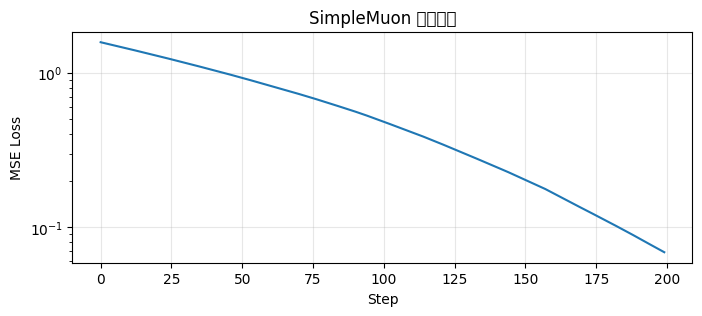

最终 loss: 0.068731


In [4]:
class SimpleMuon(torch.optim.Optimizer):
    """
    Muon 的简化单 GPU 实现 (教学版)
    """
    def __init__(self, params, lr=0.02, momentum=0.95, nesterov=True, ns_steps=5):
        defaults = dict(lr=lr, momentum=momentum, nesterov=nesterov, ns_steps=ns_steps)
        super().__init__(list(params), defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group['lr']
            momentum = group['momentum']
            nesterov = group['nesterov']
            ns_steps = group['ns_steps']

            for p in group['params']:
                if p.grad is None:
                    continue
                g = p.grad

                state = self.state[p]
                if 'momentum_buffer' not in state:
                    state['momentum_buffer'] = torch.zeros_like(g)
                buf = state['momentum_buffer']

                # 1. Momentum update
                buf.lerp_(g, 1 - momentum)
                # 2. Nesterov
                g = g.lerp_(buf, momentum) if nesterov else buf
                # 3. Newton-Schulz orthogonalization
                g = zeropower_via_newtonschulz5(g, steps=ns_steps)
                # 4+5. Aspect ratio scaling + update
                scale = max(1, p.size(-2) / p.size(-1)) ** 0.5
                p.add_(g, alpha=-lr * scale)


# Demo: 用 Muon 优化一个简单目标
torch.manual_seed(0)
W = nn.Parameter(torch.randn(16, 8))  # 2D 矩阵参数
target = torch.randn(16, 8)

optimizer = SimpleMuon([W], lr=0.02, momentum=0.95)
losses = []

for step in range(200):
    loss = ((W - target) ** 2).mean()
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    losses.append(loss.item())

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('MSE Loss')
plt.title('SimpleMuon 优化过程')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()
print(f'最终 loss: {losses[-1]:.6f}')

## 5. 参数分组策略

**Muon 只能用于 2D 矩阵参数**，其他参数仍用 AdamW。

### nanochat 的分组

| 参数组 | 优化器 | 学习率 | 说明 |
|--------|--------|--------|------|
| `transformer.h.*` (Transformer blocks) | Muon | 0.02 | 所有 Linear 层的 2D 权重 |
| `transformer.wte.*` (Embedding) | AdamW | 0.2 × scale | 词嵌入，稀疏访问 |
| `lm_head.*` (输出层) | AdamW | 0.004 × scale | 输出映射 |

其中 `scale = (model_dim / 768)^{-0.5}`，用于在不同模型尺寸间转移学习率。

### 为什么 Embedding 和 LM Head 不能用 Muon?

1. **Embedding**: 虽然是 2D (vocab_size × dim)，但每次只更新被访问的行，正交化会扰乱未更新的行
2. **LM Head**: 与 embedding 类似，且是模型输出层，对稳定性要求高
3. **1D 参数** (bias, norm): Muon 要求至少 2D

In [5]:
# 展示 nanochat 的 setup_optimizers 参数分配逻辑

setup_code = '''
# nanochat/gpt.py: setup_optimizers (简化版)

def setup_optimizers(self, matrix_lr=0.02, embedding_lr=0.2, unembedding_lr=0.004):
    # 按角色分成三组
    matrix_params    = list(self.transformer.h.parameters())   # Transformer blocks
    embedding_params = list(self.transformer.wte.parameters()) # 词嵌入
    lm_head_params   = list(self.lm_head.parameters())         # 输出层

    # LR 随模型宽度缩放: ∝ 1/√(d_model/768)
    dmodel_lr_scale = (model_dim / 768) ** -0.5

    # AdamW: embedding + lm_head
    adamw_optimizer = AdamW([
        {"params": lm_head_params,   "lr": unembedding_lr * dmodel_lr_scale},
        {"params": embedding_params, "lr": embedding_lr * dmodel_lr_scale},
    ], betas=(0.8, 0.95), eps=1e-10)

    # Muon: 所有 Transformer block 内的矩阵
    muon_optimizer = Muon(matrix_params, lr=matrix_lr, momentum=0.95)

    return [adamw_optimizer, muon_optimizer]
'''
print(setup_code)


# nanochat/gpt.py: setup_optimizers (简化版)

def setup_optimizers(self, matrix_lr=0.02, embedding_lr=0.2, unembedding_lr=0.004):
    # 按角色分成三组
    matrix_params    = list(self.transformer.h.parameters())   # Transformer blocks
    embedding_params = list(self.transformer.wte.parameters()) # 词嵌入
    lm_head_params   = list(self.lm_head.parameters())         # 输出层

    # LR 随模型宽度缩放: ∝ 1/√(d_model/768)
    dmodel_lr_scale = (model_dim / 768) ** -0.5

    # AdamW: embedding + lm_head
    adamw_optimizer = AdamW([
        {"params": lm_head_params,   "lr": unembedding_lr * dmodel_lr_scale},
        {"params": embedding_params, "lr": embedding_lr * dmodel_lr_scale},
    ], betas=(0.8, 0.95), eps=1e-10)

    # Muon: 所有 Transformer block 内的矩阵
    muon_optimizer = Muon(matrix_params, lr=matrix_lr, momentum=0.95)

    return [adamw_optimizer, muon_optimizer]



## 6. Aspect Ratio Scaling

Muon 在更新参数时，会根据矩阵的形状调整学习率:

```python
scale = max(1, rows / cols) ** 0.5
p -= lr * scale * G_orthogonalized
```

### 为什么需要?

正交化后的矩阵，其 Frobenius 范数取决于 `min(rows, cols)`。
对于 "瘦高" 矩阵 (rows >> cols)，正交化结果的范数偏小，
需要乘以 `sqrt(rows/cols)` 来补偿。

对于 "宽矮" 矩阵 (cols >= rows)，`max(1, rows/cols) = 1`，不需要调整。

In [6]:
# 展示不同形状矩阵的 aspect ratio scale

shapes = [
    (768, 768),    # 方阵 (self-attn QKV, etc.)
    (768, 2048),   # 宽矮 (FFN down-proj)
    (2048, 768),   # 瘦高 (FFN up-proj)
    (768, 3072),   # 宽矮
    (3072, 768),   # 瘦高
    (4096, 4096),  # 大方阵
    (4096, 11008), # 大 FFN down
    (11008, 4096), # 大 FFN up
]

print(f'{"Shape":>16s}  {"rows/cols":>10s}  {"scale":>8s}')
print('-' * 40)
for h, w in shapes:
    ratio = h / w
    scale = max(1, ratio) ** 0.5
    marker = ' ◀ scaled' if scale > 1.0 else ''
    print(f'{str((h,w)):>16s}  {ratio:>10.3f}  {scale:>8.4f}{marker}')

           Shape   rows/cols     scale
----------------------------------------
      (768, 768)       1.000    1.0000
     (768, 2048)       0.375    1.0000
     (2048, 768)       2.667    1.6330 ◀ scaled
     (768, 3072)       0.250    1.0000
     (3072, 768)       4.000    2.0000 ◀ scaled
    (4096, 4096)       1.000    1.0000
   (4096, 11008)       0.372    1.0000
   (11008, 4096)       2.688    1.6394 ◀ scaled


## 7. 分布式 DistMuon

在多 GPU 训练中，DistMuon 使用 **Block-cyclic 分配** + **reduce_scatter / all_gather** 模式。

### Block-cyclic 分配

参数按 shape 分组后，每 `world_size` 个参数为一个 block，
block 内的第 `i` 个参数由 rank `i` 负责计算 (momentum + NS + 更新)。

```
参数列表 (同 shape): [p0, p1, p2, p3, p4, p5, p6, p7]
world_size = 4

Block 0: p0→rank0, p1→rank1, p2→rank2, p3→rank3
Block 1: p4→rank0, p5→rank1, p6→rank2, p7→rank3
```

### 通信模式

```
1. reduce_scatter:  所有 rank 的梯度 → 平均后分片给 owner
   [G0_r0, G0_r1, G0_r2, G0_r3] → owner rank0 得到 avg(G0)

2. Owner 本地计算:  momentum → Nesterov → NS5 → aspect scale → update
   (只有 owner 维护 momentum buffer，节省显存)

3. all_gather:      owner 广播更新后的参数给所有 rank
   rank0 的 p0_updated → 所有 rank 得到 p0_updated
```

### 对比 DistAdamW

| | DistAdamW | DistMuon |
|---|---|---|
| 分片方式 | 按张量内部切片 (行切分) | 按参数分配 (整个张量给一个 rank) |
| 通信量 | 相同 (reduce_scatter + all_gather) | 相同 |
| 状态 | 每个 rank 存 1/N 的 m, v | 只有 owner 存 momentum buffer |
| 计算 | 每个 rank 算 1/N 片段 | owner 算整个张量的 NS 迭代 |

In [7]:
# DistMuon 分布式流程伪代码

dist_muon_pseudo = '''
class DistMuon:
    def __init__(self, params):
        # 按 shape 分组 (确保跨 rank 顺序一致)
        shapes = sorted({p.shape for p in params})
        for shape in shapes:
            group_params = [p for p in params if p.shape == shape]
            # 预分配 zero buffer 用于 padding 不完整的 block
            group["zero_buffer"] = torch.zeros_like(group_params[0])

    def step(self):
        rank = dist.get_rank()
        world_size = dist.get_world_size()

        # Phase 1: reduce_scatter (async)
        for group in param_groups:
            for base_i in range(0, len(params), world_size):
                owner_idx = base_i + rank
                rs_input = [p.grad for p in params[base_i:base_i+world_size]]
                rs_input += [zero_buffer] * padding   # 补齐不完整 block
                rs_output = params[owner_idx].grad     # owner 接收平均梯度
                dist.reduce_scatter(rs_output, rs_input, op=AVG, async_op=True)

        # Phase 2: owner 计算 + all_gather (async)
        for group in param_groups:
            for base_i in range(0, len(params), world_size):
                wait(reduce_scatter)  # 等待对应的 reduce_scatter 完成

                if owner_idx < len(params):  # 我是这个参数的 owner
                    g = params[owner_idx].grad  # 已经是平均后的梯度
                    buf.lerp_(g, 1-momentum)    # momentum
                    g = g.lerp_(buf, momentum)  # Nesterov
                    g = NS5(g)                  # 正交化
                    p -= lr * scale * g          # 更新

                dist.all_gather(all_ranks_params, owner_param, async_op=True)

        # Phase 3: 等待所有 all_gather 完成
        torch.futures.collect_all(futures).wait()
'''
print(dist_muon_pseudo)


class DistMuon:
    def __init__(self, params):
        # 按 shape 分组 (确保跨 rank 顺序一致)
        shapes = sorted({p.shape for p in params})
        for shape in shapes:
            group_params = [p for p in params if p.shape == shape]
            # 预分配 zero buffer 用于 padding 不完整的 block
            group["zero_buffer"] = torch.zeros_like(group_params[0])

    def step(self):
        rank = dist.get_rank()
        world_size = dist.get_world_size()

        # Phase 1: reduce_scatter (async)
        for group in param_groups:
            for base_i in range(0, len(params), world_size):
                owner_idx = base_i + rank
                rs_input = [p.grad for p in params[base_i:base_i+world_size]]
                rs_input += [zero_buffer] * padding   # 补齐不完整 block
                rs_output = params[owner_idx].grad     # owner 接收平均梯度
                dist.reduce_scatter(rs_output, rs_input, op=AVG, async_op=True)

        # Phase 2: owner 计算 + all_gather (async)
        for group in par

## 8. Momentum Schedule

nanochat 训练中，Muon 的 momentum 从 **0.85 warmup 到 0.95**。

### 为什么需要 warmup?

训练初期梯度噪声大，低 momentum (0.85) 让优化器更关注当前梯度。
随着训练进行，梯度方向趋于稳定，可以加大 momentum (0.95) 来加速收敛。

### 实现方式

在训练循环中，通常用线性插值调整:

```python
momentum = 0.85 + (0.95 - 0.85) * min(1, step / warmup_steps)
for group in muon_optimizer.param_groups:
    group['momentum'] = momentum
```

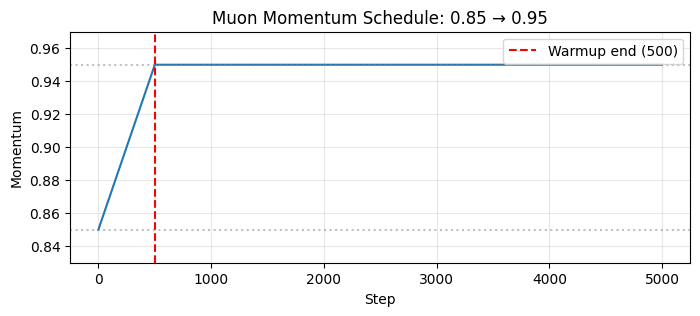

In [8]:
# 可视化 momentum schedule

total_steps = 5000
warmup_steps = 500
momentum_start = 0.85
momentum_end = 0.95

steps = range(total_steps)
momentums = []
for s in steps:
    t = min(1.0, s / warmup_steps)
    mom = momentum_start + (momentum_end - momentum_start) * t
    momentums.append(mom)

plt.figure(figsize=(8, 3))
plt.plot(steps, momentums)
plt.axvline(x=warmup_steps, color='r', linestyle='--', label=f'Warmup end ({warmup_steps})')
plt.axhline(y=momentum_start, color='gray', linestyle=':', alpha=0.5)
plt.axhline(y=momentum_end, color='gray', linestyle=':', alpha=0.5)
plt.xlabel('Step')
plt.ylabel('Momentum')
plt.title('Muon Momentum Schedule: 0.85 → 0.95')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.83, 0.97)
plt.show()

## 9. 面试常见问题

### Q1: Muon 和 AdamW 的核心区别是什么?

**答**: AdamW 对每个标量参数独立自适应 (逐元素 `m/√v`)；Muon 对整个权重矩阵做 SVD 级别的正交化，让所有奇异方向的步长一致。Muon 只适用于 2D 矩阵参数。

---

### Q2: Newton-Schulz 迭代为什么用 bfloat16?

**答**: NS 迭代只涉及矩阵乘法和加法，bfloat16 的精度完全够用，而且速度更快。最终结果本身就不精确 (S' ~ Uniform(0.5, 1.5))，所以 bfloat16 引入的误差无影响。

---

### Q3: 为什么 NS 只跑 5 步不跑到收敛?

**答**: 完全收敛需要更多步 (> 10 步)，但实验表明 5 步的近似正交化已经足够好。不完全收敛意味着奇异值在 [0.5, 1.5] 而不是精确的 1.0，但这不影响训练效果——重点是"均匀化"而非"精确到 1"。

---

### Q4: Muon 的显存优势是什么?

**答**: AdamW 每个参数需要 m + v 两个状态 (8 bytes/param for FP32)。Muon 只需要一个 momentum buffer (4 bytes/param)。对于 Transformer blocks 中大量的 2D 参数，显存节省显著。

---

### Q5: DistMuon 和 DistAdamW 的分布式策略有何不同?

**答**: DistAdamW 切分张量内部 (每个 rank 负责 1/N 行)；DistMuon 按整个参数分配 (整个张量交给一个 rank)。原因是 NS 迭代涉及整个矩阵的乘法 (`X @ X^T`)，无法按行切分。

---

### Q6: 为什么 Embedding 不能用 Muon?

**答**: Embedding 的梯度是稀疏的 (只有被 lookup 的行有梯度)。对稀疏梯度做正交化，会把零梯度的行也"搅进来"，破坏未被访问词的嵌入。此外，Muon 原论文也建议 embedding 和 lm_head 用标准优化器。

## 10. 总结速查表

| 主题 | 要点 |
|------|------|
| **算法** | SGD-Momentum → Nesterov → Newton-Schulz 正交化 → Aspect Scaling |
| **NS 系数** | a=3.4445, b=-4.7750, c=2.0315 (五次多项式，最大化零点斜率) |
| **NS 精度** | bfloat16 即可；5 步近似，S' ~ Uniform(0.5, 1.5) |
| **Aspect Scaling** | `max(1, rows/cols)^0.5`，补偿瘦高矩阵 |
| **参数分组** | Muon: Transformer blocks (2D 矩阵)；AdamW: embedding + lm_head |
| **显存** | 只需 1 个 momentum buffer (vs AdamW 的 m + v) |
| **分布式** | Block-cyclic 分配，reduce_scatter → owner 计算 → all_gather |
| **Momentum** | 0.95 (可从 0.85 warmup) |
| **学习率** | 默认 0.02 (不随 d_model 缩放，区别于 AdamW 组) |

### nanochat 使用的配置

```python
# nanochat/gpt.py: setup_optimizers
muon_kwargs = dict(lr=0.02, momentum=0.95)
adamw_kwargs = dict(betas=(0.8, 0.95), eps=1e-10, weight_decay=0.0)

# 参数分配
Muon:  self.transformer.h.parameters()      # 所有 Transformer block 参数
AdamW: self.transformer.wte.parameters()     # Embedding
AdamW: self.lm_head.parameters()             # 输出层
```

## 参考资料

- [Muon: An optimizer for hidden layers in neural networks](https://kellerjordan.github.io/posts/muon/)
- [Newton-Schulz iteration (Wikipedia)](https://en.wikipedia.org/wiki/Newton%27s_method#Matrix_equations)
- nanochat/muon.py — Muon 和 DistMuon 实现
- nanochat/gpt.py:215-243 — setup_optimizers 参数分组